# Random Forest
- Random Forest is an ensemble learning algorithm that builds multiple decision trees 
using bootstrapped datasets and random feature selection, and combines their 
predictions to improve accuracy and reduce overfitting.

- Think of a Random Forest as the ultimate "wisdom of the crowd" approach to 
decision-making.

Instead of trusting a single expert (one Decision Tree) who might be biased or fixated on a single detail, a Random Forest asks an entire committee of experts (a forest of Decision Trees) to vote. The majority vote wins. 

- Random Forest is a Supervised Machine Learning algorithm used for both:

    - Classification (Predict categories)
    - Regression (Predict numerical values)

- It uses:

    - Bootstrapping (Bagging)
    - Random Feature Selection

This reduces overfitting and improves prediction accuracy.

# What are Ensembles?

- The word “Ensemble” is taken from music background which means: Group of 
Musicians.

- Similarly, instead of depending on one machine learning model, we combine multiple models.
The combined model usually performs much better. This idea is called Ensemble Learning.

- This approach harnesses the collective strength of diverse models to improve 
performance and reduce errors.

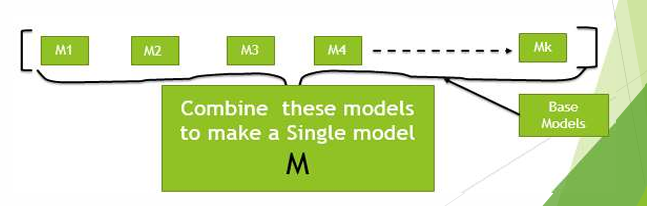

## Types of Ensemble Learning

### 1. Bagging (Bootsrap Aggeagation)
eg. Random Forest

- Goal :
  - Reduce variance and overfitting.
  - Models are built independently.
  - Finally, predictions are combined.

### 2. Boosting
eg. AdaBoost, Gradient Boosting, XGBoost

- Goal :
  - Reduce previous mistakes.
  - Models are trained one after another.
  - Each new model tries to fix errors of the previous one.

- These are high performing model 
- These models are very powerful and popular.

#### Why Random Forest was created?
Decision Trees are powerful but have one major issue that they often memorize the training data, this is called overfitting. Random Forest solves this problem using Bagging.

## Bagging (Bootstrapping)
- It is also called Bootstrap Aggregation : Means sampling with 'replacement'.
- If decision tree suffered from problem of overfitting we can use concept of bagging.
-  Where overfitting means your model have good training accuracy but poor testing 
accuracy, in general thumb rule if difference between training and testing accuracy is 
more than 10 % we can say it is over fitted.
- Random Forest is the most popular implementation of Bagging used in real-world 
applications.

##### - Bagging is especially effective for reducing variance in high-variance, low-bias models (e.g., deep decision trees)
##### - It does not inherently address bias, so if the base model is underfitting, bagging won't help much.
##### - So Bagging reduces variance without impacting the bias(under fitting)

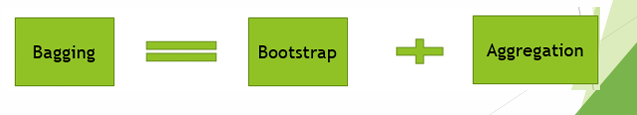

#### Why do we create multiple samples?
Instead of training one tree, we create a number of dataset and their decision trees. Each tree sees a slightly different version of the data. Therefore, each tree learns differently.
#### Aggreagtion :
After every tree predicts, we combine all predictions.

For Classification :
    - Majority voting

For Regression :
    - Average Prediction

- This process is called Aggregation.

## Bagging Architecture

Original Dataset

        │
        ▼

Bootstrap Sampling

        │
        ▼

Dataset 1 → Model 1

Dataset 2 → Model 2

Dataset 3 → Model 3

...

Dataset K → Model K

        │
        ▼

Aggregation

Classification → Voting

Regression → Average

        │
        ▼

Final Prediction



- This is the core idea behiind Random Forest.

#### The 63.2% Rule: Mathematically, when you bootstrap a dataset to the same size as the original, each sample will naturally contain roughly 63.2% of the unique original rows. The remaining ~36.8% of the rows that get left out are called Out-of-Bag (OOB) data, which can be perfectly used as a built-in validation set to test the model's accuracy.

## General Error Decomposition
The total error of a model can be expressed as :

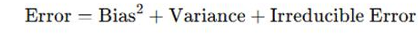

#### 1. Bias (The "Overly Simplistic" Error)
- What it means: Bias measures how far off the model's predictions are from the true 
values because the model made wrong or oversimplified assumptions about the 
data.
- High Bias --> Underfitting
- eg. Trying to fit a straight line on curved data.

- The Result: It leads to underfitting. The model is too rigid to learn the real patterns.


##### Why is it squared?
Because error calculations look at the absolute distance away from the target, squaringit ensures that positive and negative deviations don't accidentally cancel each other out.

#### 2. Variance (The "Overly Sensitive" Error) 
- What it means : Variance measures how much the model's predictions shift when 
you feed it a different set of training data.
- High Variance --> Overfitting
- Decision Tree have high variance

- The Result: It leads to overfitting. The model is so flexible that it learns the random fluctuations, tweaks, and noise in the training data rather than the actual
underlying concept.

#### 3. Irreducibe Error (The "Inherent Noise") 
- What it means: This is the baseline noise or randomness inherent in the data itself. 
No matter how perfect your algorithm is, how advanced your math is, or how much 
data you collect, you can never eliminate this error. (Noise is already present in the data.)
- eg. A student predicts his exam results but falls sick during exam. No model could predict this. That uncertainity is Irreducible Error.
- Why it exists: It happens because of missing features, imperfect measurements, or 
purely random real-world chaotic factors.

### The Target Visualization
To see how these work together, visualize these four target scenarios:

• Low Bias + Low Variance : The ideal model. Arrows are tightly grouped right in 
the bullseye. 

• High Bias + Low Variance : Underfitted. Arrows are tightly grouped together, but 
way off target. 

• Low Bias + High Variance : Overfitted. Arrows are centered around the bullseye 
on average, but scattered wildly across the board. 

• High Bias + High Variance: The worst-case scenario. Arrows are scattered wildly 
and far away from the center.

## Bagging and Model Error
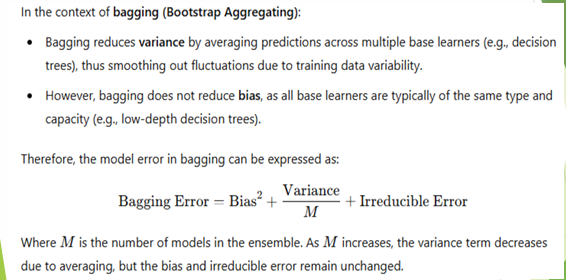
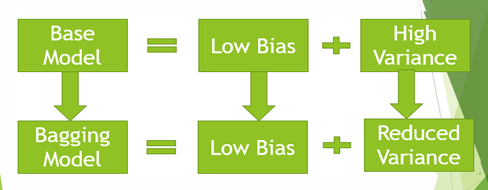

## Out-of-Bag (OOB)
- In Bagging (Bootstrap Aggregating), each base model is trained on a random subset 
of the training data, drawn with replacement. This means that some data points will 
not be included in the training subset for a particular base model. These excluded 
data points are referred to as Out-of-Bag (OOB) samples.
- In simple language, we keep some data hidden (for eg. 10-20% from the training data) and do not use this hidden data in training but it will be  used for model validation.

### Key Features of OOB :
- Not Used in Training : For a given base model, the OOB samples are not used during 
training.
- Used for Validation : The OOB samples act as a validation set for evaluating the 
performance of the base model. Essentially, they provide an estimate of how well 
the model performs on unseen data without the need for a separate validation 
dataset. 


### Key Differences Table
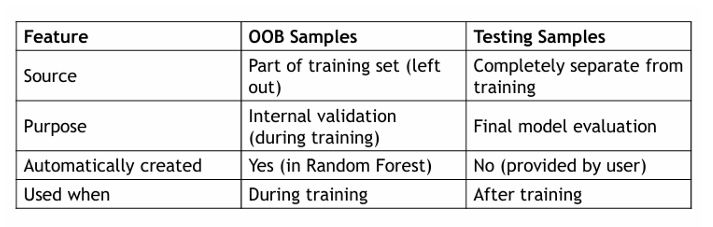

#### In nutshell what RF is doing....
###### Steps
1. Take decision tree of reasonable depth  as base learner.
2. Row and column sampling with replacement.
3. Model building.
4. Aggregation(Based on Majority) : For Classification problem - Majority Voting and for Regression problem based on mean and median.

- We are using Random Forest for handling overfitting problem.
- Random Forest does not require any outlier treatment.
- Data balancing required. 

### Important RF Hyperparameters
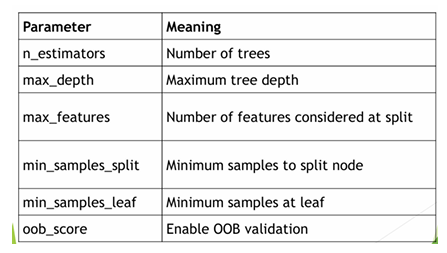

### Advantages
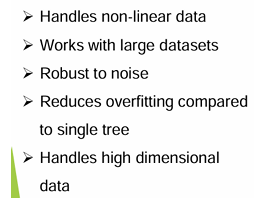

### Limitations
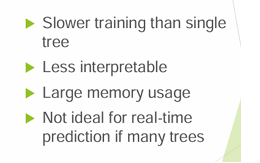

### Practice 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = pd.read_csv(r"C:\Users\saiha\OneDrive\Documents\Python\APPLIEDDATASCIENCEwithPYTHON\ML\Churn_Modelling.csv")
# churn means: A customer stops using the company's service.
# exited=1 :  customer left that company(bank)
# exited=0 : customer stayed with the company

In [3]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
dataset.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [5]:
dataset.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
dataset.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
dataset = dataset.drop(columns=['RowNumber', 'CustomerId','Surname'])

In [9]:
dataset.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
# Encoding

dataset['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [11]:
dataset['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [12]:
# Label Encoding

dataset['Gender'] = dataset['Gender'].astype('category') 
dataset['Gender'] = dataset['Gender'].cat.codes 
# .cat.codes replaces every category with an integer code.

In [13]:
dataset['Gender']

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    1
9997    0
9998    1
9999    0
Name: Gender, Length: 10000, dtype: int8

In [14]:
# One Hot Encoding

dataset = pd.get_dummies(dataset, columns=['Geography'], drop_first=True)

In [15]:
dataset.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int8   
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(2), int64(7), int8(1)
memory usage: 732.6 KB


In [17]:
# To know about unique values and their count

for col in dataset.columns:
    print('*****'*10,col,'*****'*10)
    print('Unique Values:', dataset[col].unique())
    print()
    print('Count:', dataset[col].nunique())
    print()

************************************************** CreditScore **************************************************
Unique Values: [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 680 749 734

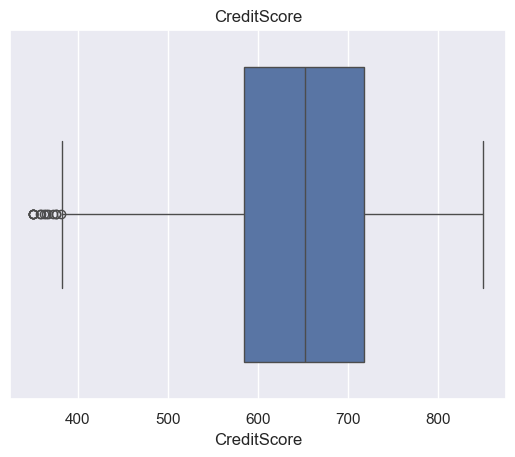

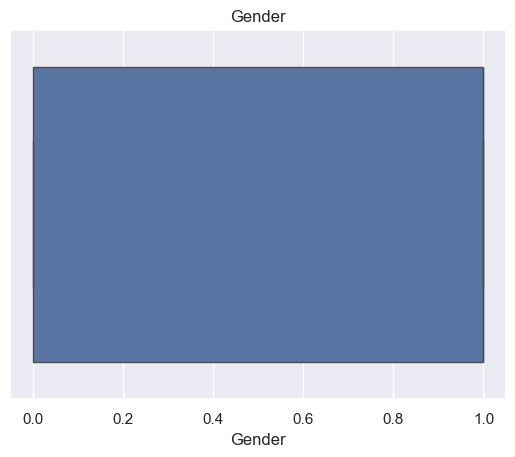

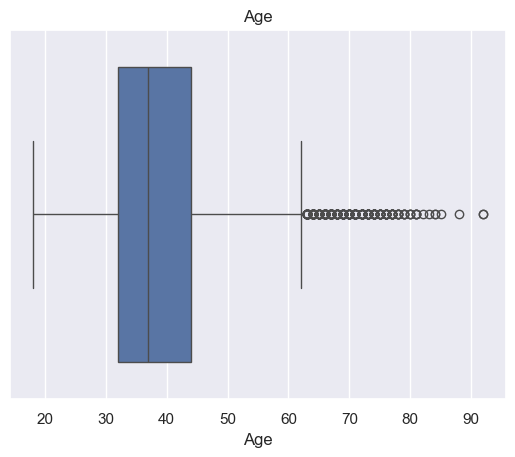

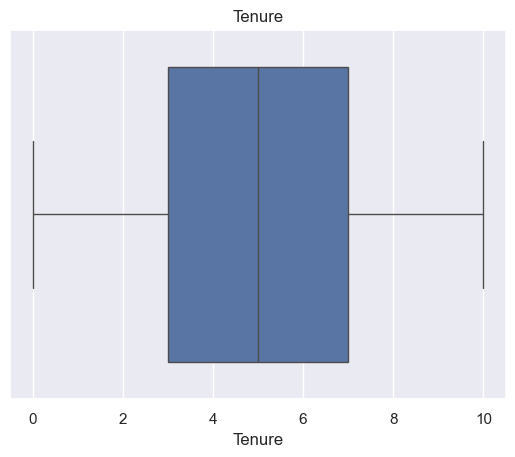

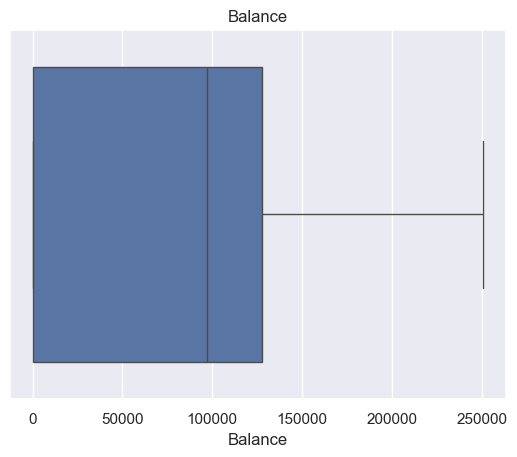

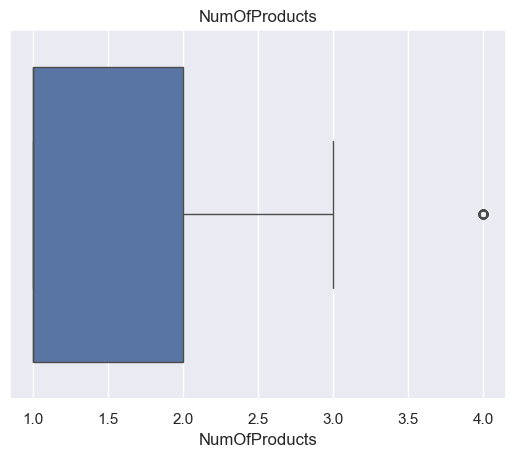

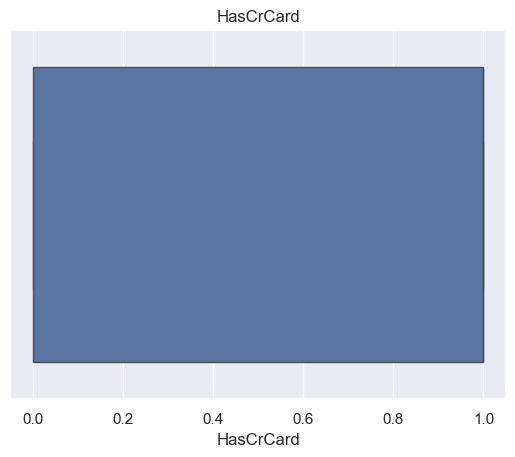

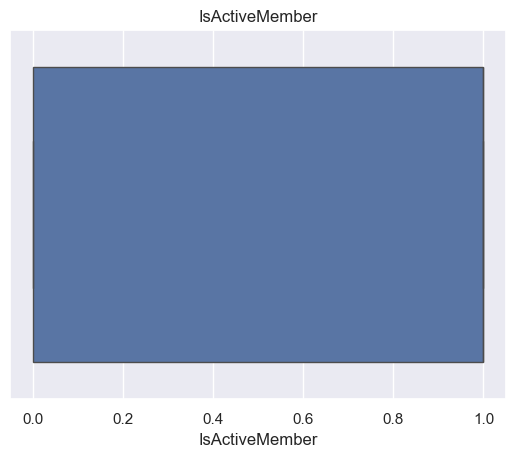

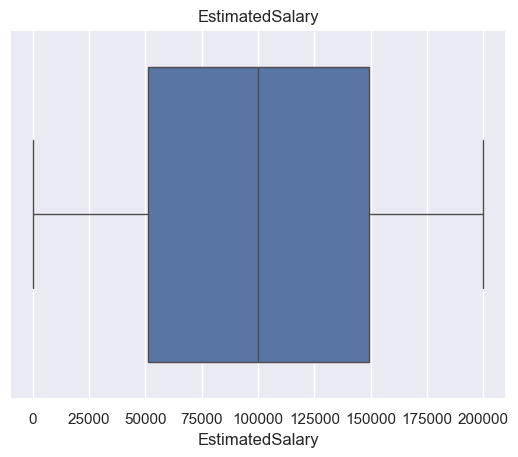

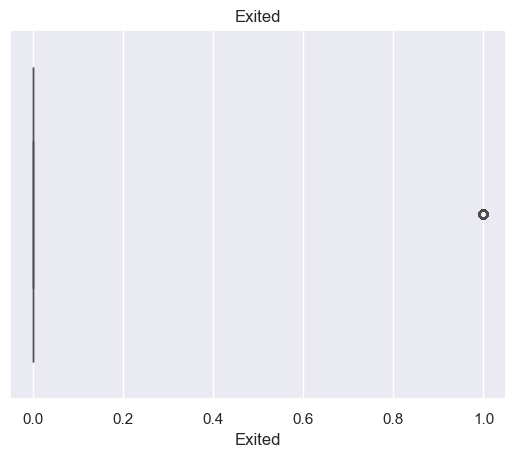

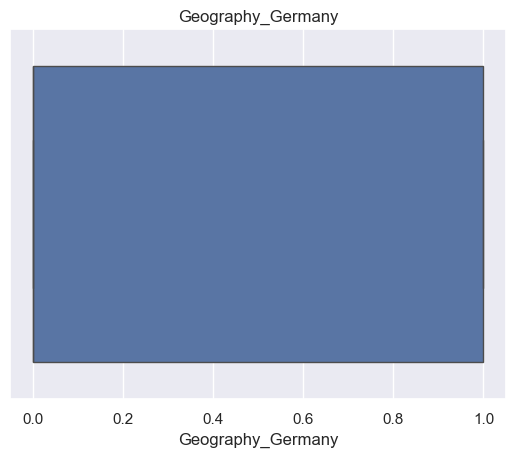

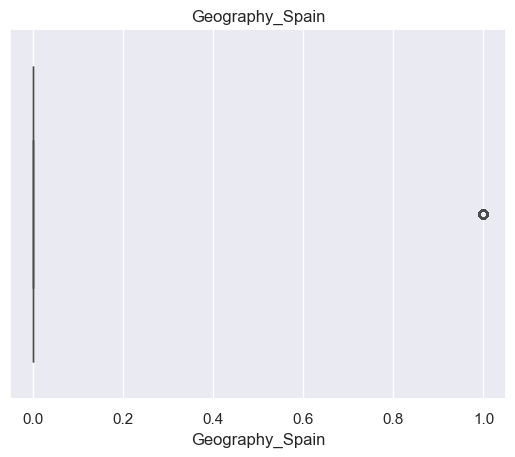

In [18]:
def boxplot(df, col):
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

num_cols = dataset.select_dtypes(exclude=['object']).columns
for col in num_cols:
    boxplot(dataset,col)

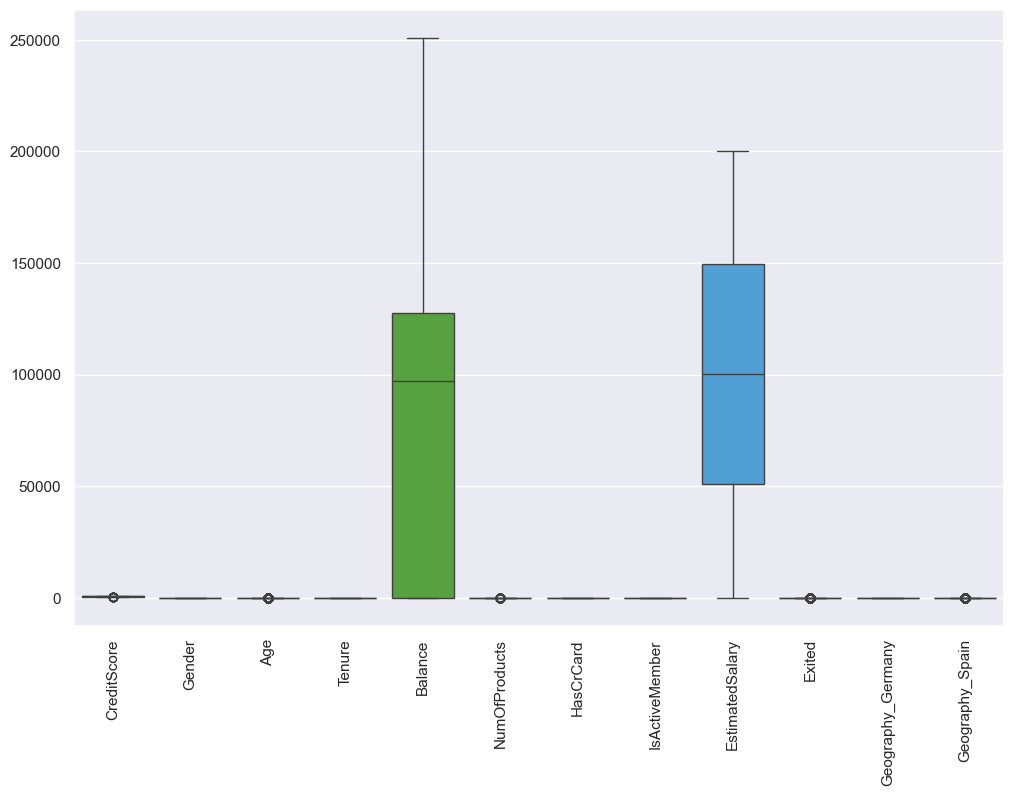

In [19]:
# if you want to plot all the boxplots in one figure

plt.figure(figsize=(12,8))
sns.boxplot(data=dataset.select_dtypes(exclude='object'))
plt.xticks(rotation=90)
plt.show()

#### Split the data into independent and dependent variable

In [20]:
x = dataset.drop(['Exited'], axis=1)
y = dataset[['Exited']]

In [21]:
x.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


In [22]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


#### Feature Scaling required

In [23]:
from sklearn.preprocessing import StandardScaler 
# StandardScaler is a preprocessing tool used to standardize your features. 
# It takes variables that are measured in completely different units (like Age in years vs. Salary in thousands of dollars) and puts them on the same mathematical scale.
# This tells us how many standard deviations a value is away from the mean.

sc = StandardScaler()
x1 = sc.fit_transform(x)
# Learn the scaling parameters, then immediately apply them

In [24]:
pd.DataFrame(x1).head()

,0,1,2,3,4,5,6,7,8,9,10
0,-0.326221,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,-0.578736,-0.573809
1,-0.440036,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-0.578736,1.742740
2,-1.536794,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,-0.578736,-0.573809
3,0.501521,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,-0.578736,-0.573809
4,2.063884,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.578736,1.742740


In [25]:
# Check Imbalance dataset

y.value_counts()

Exited
0         7963
1         2037
Name: count, dtype: int64

#### As data is not balanced, we need to do data balancing
| Random Over Sampling          | SMOTE                                               |
| ----------------------------- | --------------------------------------------------- |
| Copies existing samples       | Creates new synthetic samples                       |
| Very simple                   | More advanced                                       |
| Can overfit due to duplicates | Less likely to overfit                              |
| Faster                        | Slightly slower                                     |
| Good for quick balancing      | Usually preferred for continuous numerical features |


In [26]:
import imblearn
from imblearn.over_sampling import RandomOverSampler, SMOTE

ros =  RandomOverSampler() 
x_sam_ros, y_sam_ros = ros.fit_resample(x1,y)

smo = SMOTE()
x_sam_smo, y_sam_smo = smo.fit_resample(x1,y)

In [27]:
print(x_sam_ros.shape, y_sam_ros.shape, y.shape)

(15926, 11) (15926, 1) (10000, 1)


In [28]:
y_sam_ros.value_counts() 

Exited
0         7963
1         7963
Name: count, dtype: int64

In [29]:
y.value_counts() 

Exited
0         7963
1         2037
Name: count, dtype: int64

In [30]:
print(x_sam_smo.shape, y_sam_smo.shape, y.shape)

(15926, 11) (15926, 1) (10000, 1)


In [31]:
dataset.corr() 

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Exited,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


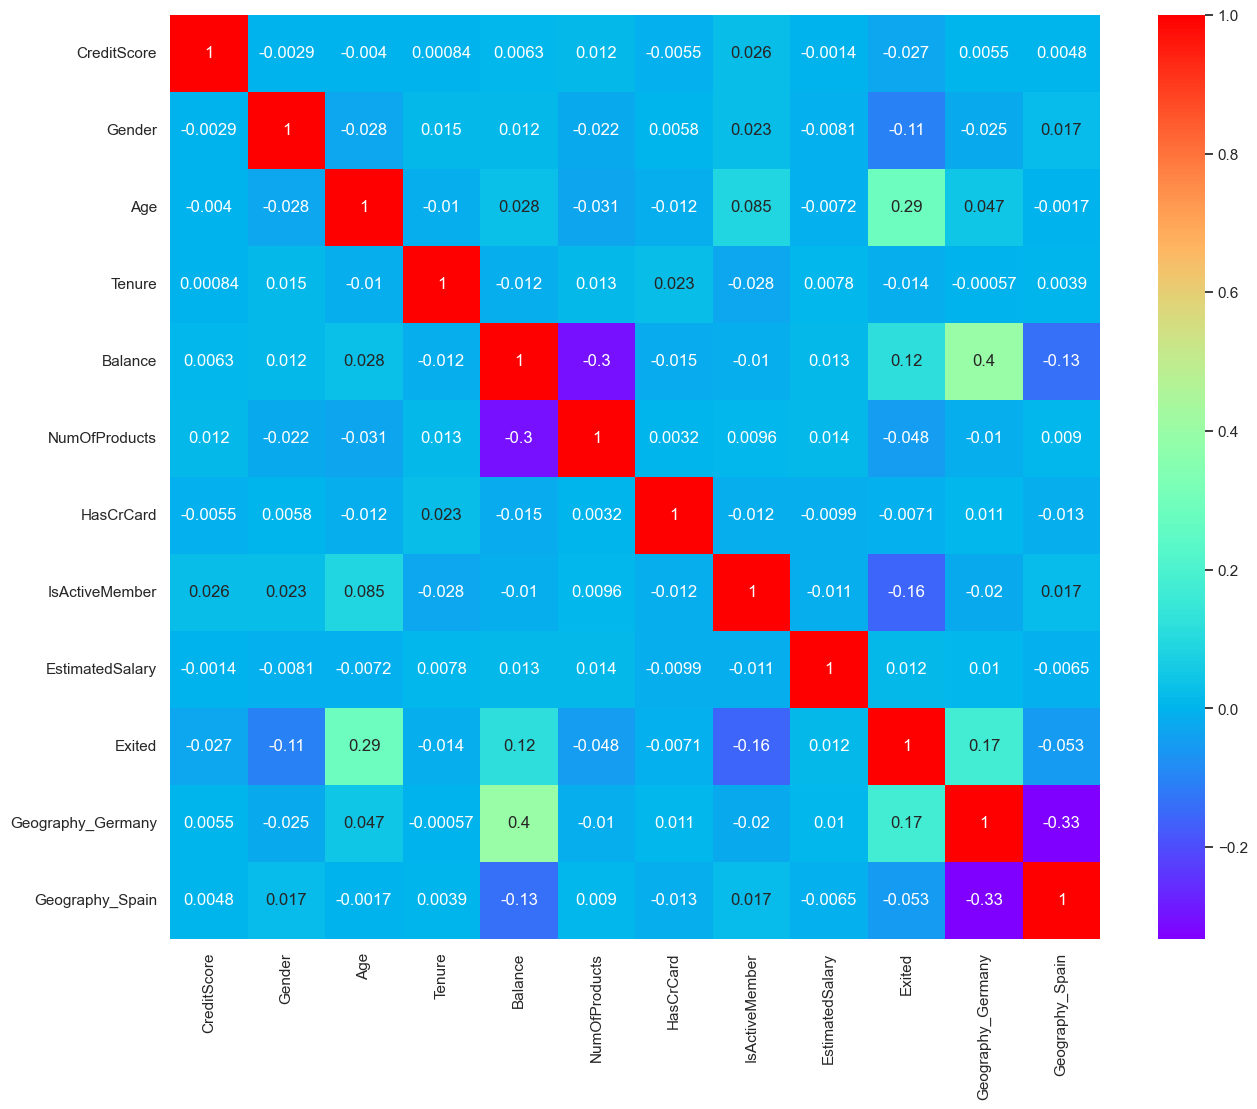

In [32]:
plt.figure(figsize=(15,12))
sns.heatmap(dataset.corr(), annot=True, cmap='rainbow')
plt.show()

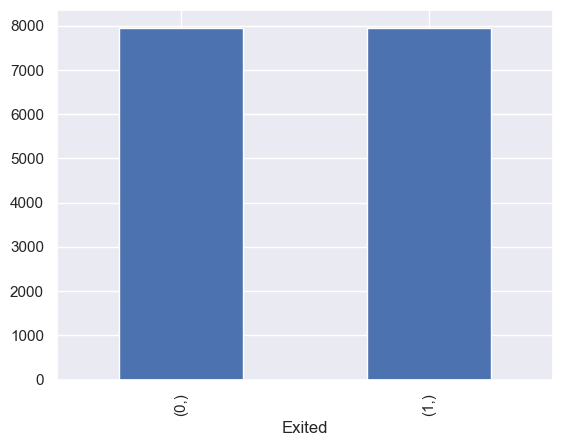

In [33]:
pd.DataFrame(y_sam_ros).value_counts().plot(kind='bar')
plt.show()

<Axes: xlabel='Exited'>

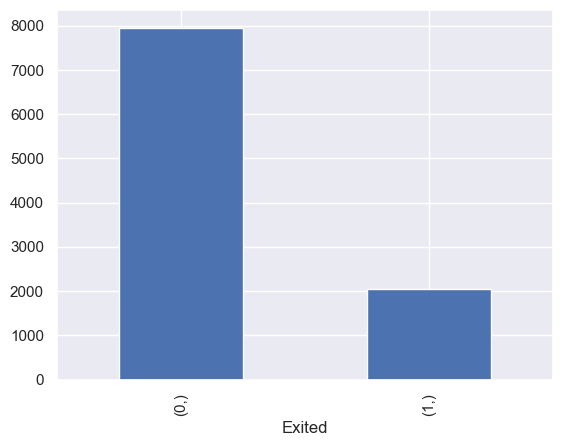

In [34]:
pd.DataFrame(y).value_counts().plot(kind='bar')

In [35]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int8   
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(2), int64(7), int8(1)
memory usage: 732.6 KB


In [36]:
# keep only non-boolean columns from x

x1 = [col for col in x if dataset[col].dtype != 'bool']
print(x1)

# x1 = []
# for col in x:
#     if dataset[col].dtype != 'bool':
#         x1.append(col)

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [37]:
def histograms(dataset, variables, n_rows, n_cols):
    fig = plt.figure(figsize=(20,15))
    for i, var_name in enumerate(variables):  #enumerate() gives both the index and the value.
        ax = fig.add_subplot(n_rows, n_cols, i+1)
        dataset[var_name].hist(bins=10, ax=ax)   #Bins are simply intervals (groups).
        ax.set_title(var_name + 'distribution')

    fig.tight_layout()
    plt.show()

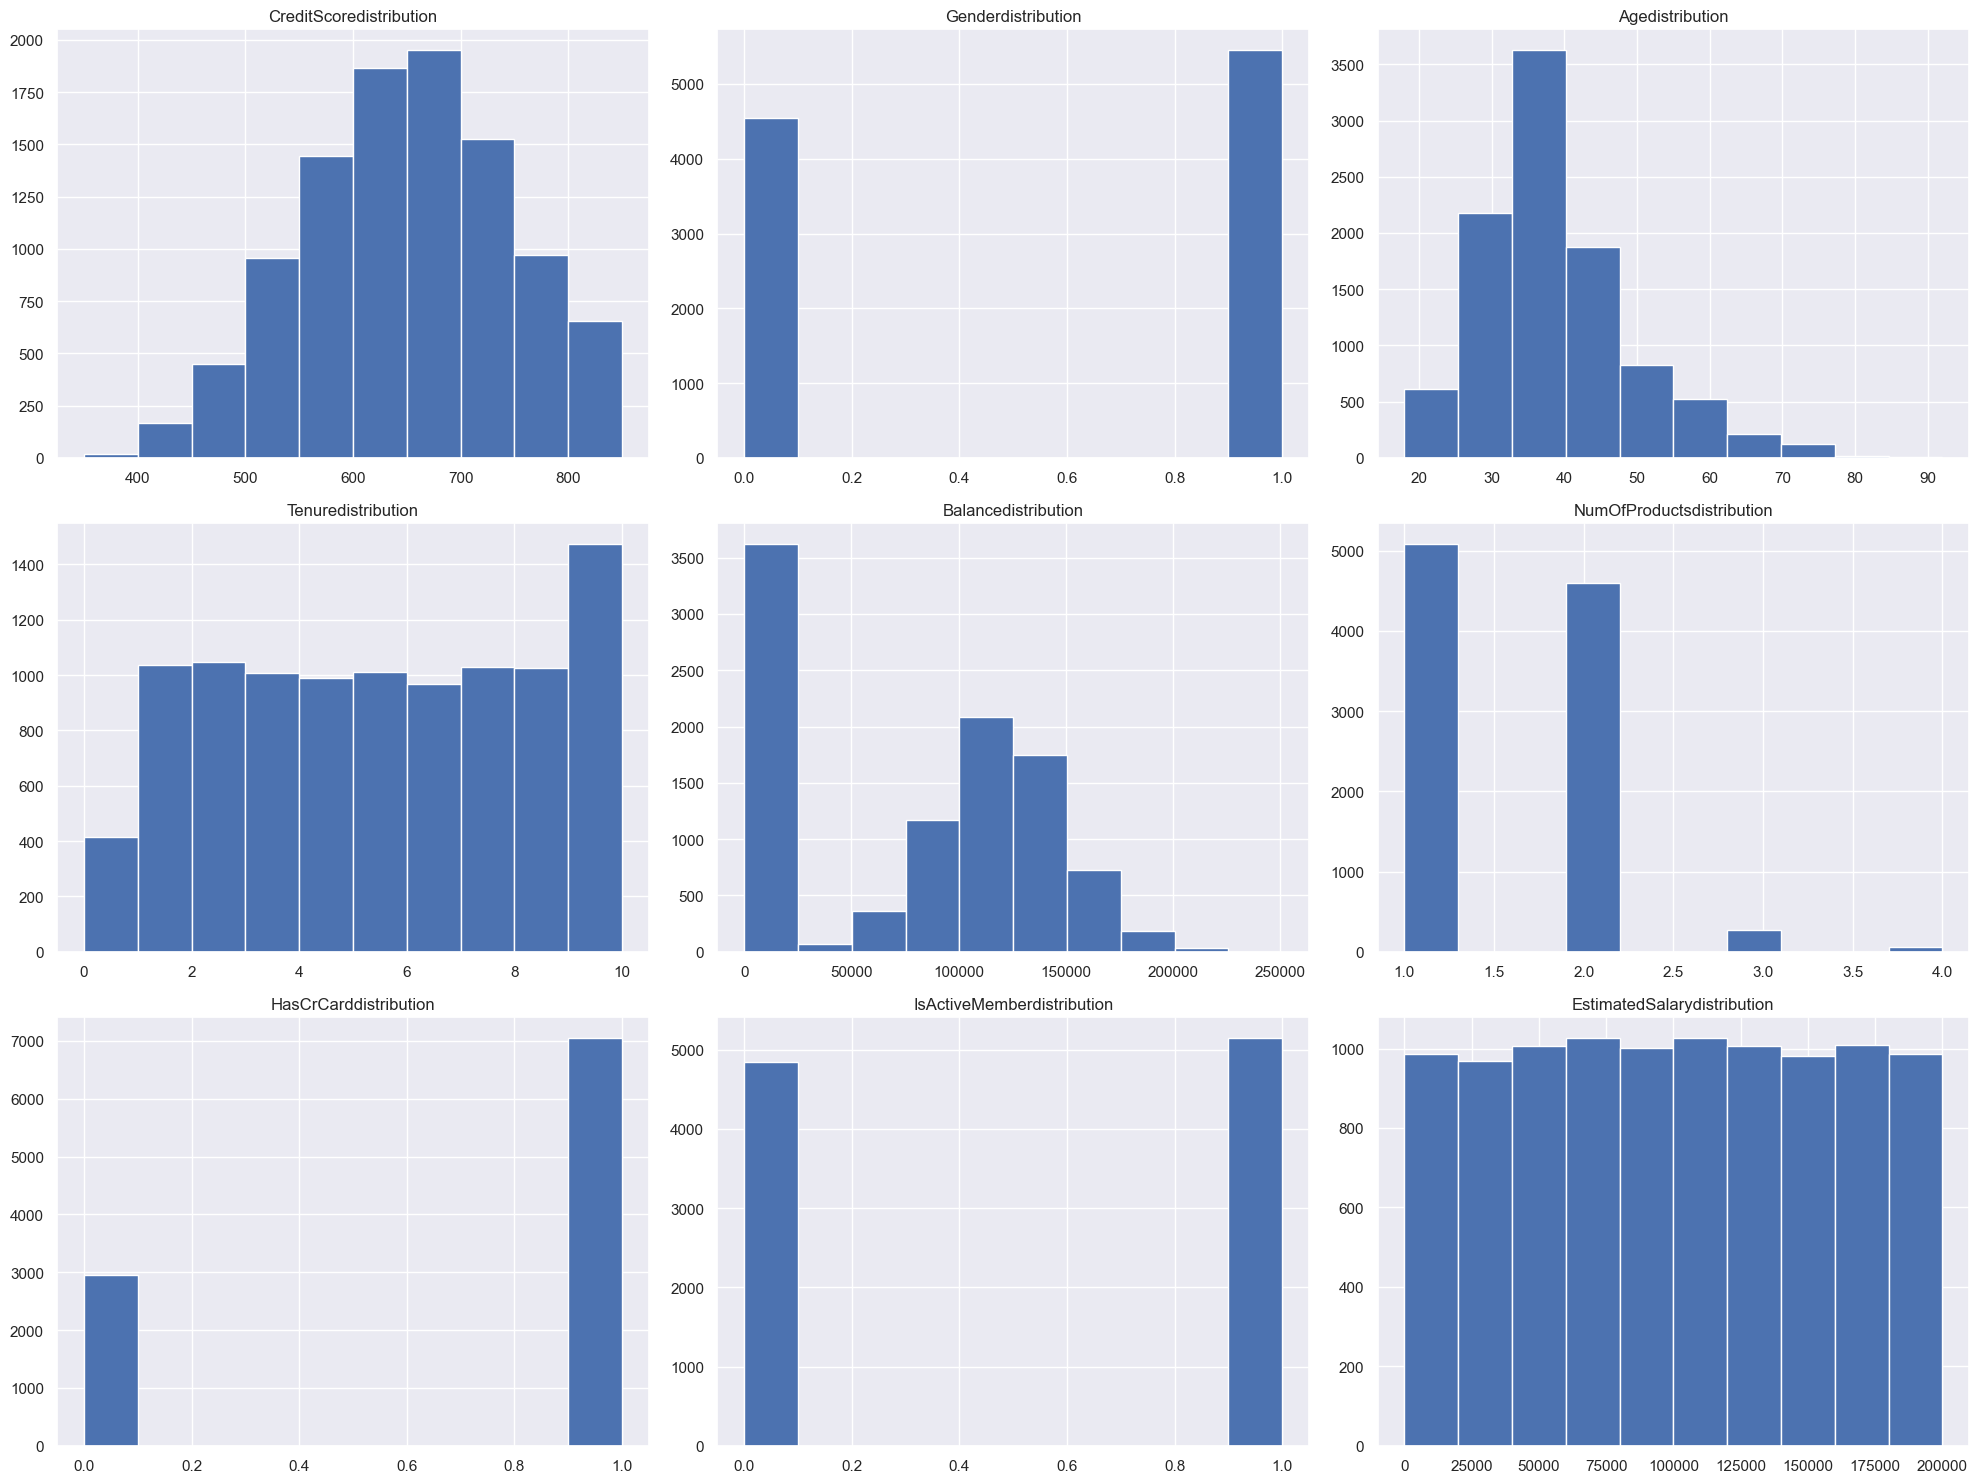

In [38]:
histograms(dataset, x1, 3, 3)

#### Adv EDA :Dtale--->D-Tale is a Python library that allows you to 
interactively explore, visualize, and edit Pandas DataFrames in your 
web browser — without writing code for every step. 

In [39]:
!pip install dtale

In [40]:
# D-Tale is a Python library that turns your Pandas DataFrame into an interactive spreadsheet that opens in your web browser.

import dtale 
import dtale.app as dtale_app

In [41]:
dtale.show(dataset)

### Split the data into training and testing

In [42]:
from sklearn.model_selection import train_test_split 

x_train, x_test, y_train, y_test = train_test_split(x_sam_ros, y_sam_ros, 
test_size=0.25, random_state=101, stratify=y_sam_ros ) 

### Building Bagging Algorithm

In [43]:
from sklearn.ensemble import BaggingClassifier 

bagging = BaggingClassifier() 
bagging.fit(x_train, y_train) 
 
y_pred_train_bgg = bagging.predict(x_train) 
y_pred_test_bgg = bagging.predict(x_test)

### Evaluate

In [44]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score 

print(confusion_matrix(y_train, y_pred_train_bgg)) 
print() 
print(confusion_matrix(y_test, y_pred_test_bgg))

[[5954   18]
 [  12 5960]]

[[1799  192]
 [  70 1921]]


In [45]:
print(classification_report(y_train, y_pred_train_bgg)) 
print() 
print(classification_report(y_test, y_pred_test_bgg)) 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5972
           1       1.00      1.00      1.00      5972

    accuracy                           1.00     11944
   macro avg       1.00      1.00      1.00     11944
weighted avg       1.00      1.00      1.00     11944


              precision    recall  f1-score   support

           0       0.96      0.90      0.93      1991
           1       0.91      0.96      0.94      1991

    accuracy                           0.93      3982
   macro avg       0.94      0.93      0.93      3982
weighted avg       0.94      0.93      0.93      3982



Precision:
- Out of all customers predicted as "left", how many actually left?

Recall:
- Out of all customers who actually left, how many did the model successfully identify?

F1 Score:
- It balances Precision and Recall into a single score.

Support:
- How many actual samples belong to each class.

In [46]:
print(accuracy_score(y_train, y_pred_train_bgg)) 
print() 
print(accuracy_score(y_test, y_pred_test_bgg)) 

0.9974882786336235

0.934203917629332


### RandomForest Classifier Model 

In [47]:
from sklearn.ensemble import RandomForestClassifier 

rf = RandomForestClassifier(n_estimators=200, criterion='entropy', bootstrap=True, oob_score=False)
# n_estimators=200 : n_estimators=200
# criterion = 'entropy': How should splits be chosen? Entropy comes from Information Gain. The tree chooses the feature that reduces uncertainty the most.
# bootstrap=True: Random sampling with replacement.
# oob_score=False: Out Of Bag validation

rf.fit(x_train, y_train) 

RandomForestClassifier(criterion='entropy', n_estimators=200)

y_pred_train_rf = rf.predict(x_train) 
y_pred_test_rf = rf.predict(x_test) 

In [48]:
print(confusion_matrix(y_train, y_pred_train_rf)) 
print() 
print(confusion_matrix(y_test, y_pred_test_rf)) 

[[5972    0]
 [   0 5972]]

[[1830  161]
 [  57 1934]]


In [49]:
print(classification_report(y_train, y_pred_train_rf)) 
print() 
print(classification_report(y_test, y_pred_test_rf)) 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5972
           1       1.00      1.00      1.00      5972

    accuracy                           1.00     11944
   macro avg       1.00      1.00      1.00     11944
weighted avg       1.00      1.00      1.00     11944


              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1991
           1       0.92      0.97      0.95      1991

    accuracy                           0.95      3982
   macro avg       0.95      0.95      0.95      3982
weighted avg       0.95      0.95      0.95      3982



In [50]:
print(accuracy_score(y_train, y_pred_train_rf)) 
print() 
print(accuracy_score(y_test, y_pred_test_rf)) 

1.0

0.945253641386238


### Applying cross validation method in RandomForest 

In [51]:
from sklearn.model_selection import cross_val_score

accuracy = cross_val_score(rf, x_train, y_train, cv=10) 
accuracy.mean()

np.float64(0.9398847094608328)

In [52]:
print(accuracy.max()) 
print(accuracy.min()) 

0.9523012552301255
0.9279731993299832


In [53]:
print("Trainging Accuracy : ", accuracy.mean()) 
print() 
print("Test Accuracy: ", accuracy_score(y_test, y_pred_test_rf))

Trainging Accuracy :  0.9398847094608328

Test Accuracy:  0.945253641386238


### Hyperparameter Tuning

#### GridSearchCV

In [55]:
rf = RandomForestClassifier(random_state=42)

In [57]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# 2 × 2 × 2 × 2 = 16 × 5 folds = 80 fits


In [58]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator= rf, param_grid=param_grid, cv=5,
                     n_jobs=-1, verbose=0 )


In [59]:
rf_grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 300]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int,

In [60]:
print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [61]:
print("Best CV Score:", rf_grid.best_score_)

Best CV Score: 0.9322667824962683


In [62]:
best_rf = rf_grid.best_estimator_

In [64]:
y_pred_test = best_rf.predict(x_test)

In [65]:
y_pred_train = best_rf.predict(x_train)

In [66]:
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))

Train Accuracy: 1.0


In [67]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9450025113008539


#### RandomSearchCV 

In [68]:
from sklearn.model_selection import RandomizedSearchCV

In [69]:
# Parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [70]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,      #Try only 10 random combinations
    cv=5,
    verbose=2,      #Show progress while training.
    random_state=42,
    n_jobs=-1       #Uses all CPU cores for parallel processing. Training becomes much faster.
)

In [71]:
# Train the model
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [72]:
# Best Parameters
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': 20,
 'criterion': 'entropy'}

In [73]:
random_search.best_score_

np.float64(0.9228063016351467)

In [74]:
best_rf_1 = random_search.best_estimator_
best_rf_1

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [75]:
from sklearn.metrics import accuracy_score

y_pred_test = best_rf_1.predict(x_test)

accuracy_score(y_test, y_pred_test)

0.9372174786539428

| Method             | Idea                      | Speed |
| ------------------ | ------------------------- | ----- |
| GridSearchCV       | tries all combinations    | slow  |
| RandomizedSearchCV | tries random combinations | fast  |



| Verbose | Output Level                |
| ------- | --------------------------- |
| 0       | No output                   |
| 1       | Basic progress              |
| 2       | More detailed progress      |
| 3       | Full detailed training info |


## Boosting (HBLV)
- Boosting is an ensemble learning technique in which multiple weak learners (usually decision trees) are trained one after another (sequentially). Each new model focuses on correcting the mistakes made by the previous model, resulting in a strong and accurate final model.

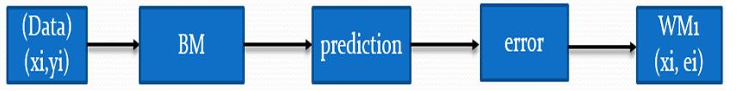

- If the base model is highly biased than boosting technique is going to help us in 
reducing the bias.


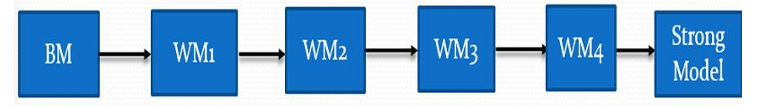

### HBLV Trick 

#### H --> High Bias
- Boosting is mainly used to reduce high bias (underfitting).
- It improves weak models by making them learn from previous mistakes.

#### B --> Bias Reduction
- Every new model tries to reduce the errors of the previous model.
- The overall bias decreases, making predictions more accurate.

#### L --> Low Variance 
- Since errors are corrected gradually, the final model usually has lower variance than a single weak learner.
- However, if boosting is pushed too far, it can also overfit.

#### V --> Voting/Weighted Voting
In the final prediction:
- Classification: Models vote (often weighted voting, where better-performing models have more influence).
- Regression: Predictions are combined using a weighted average.

#### How Boosting Works
Original Dataset
        │
        ▼
Decision Tree 1
        │
Mistakes Found
        ▼
Decision Tree 2
(Focuses on previous mistakes)
        │
Mistakes Found
        ▼
Decision Tree 3
(Focuses on remaining mistakes)
        │
        ▼
...
        ▼
Final Combined Prediction

- Unlike Bagging, where all trees are built independently, in Boosting each tree depends on the previous one.

#### Bagging vs Boosting
| Bagging                           | Boosting                                                  |
| --------------------------------- | --------------------------------------------------------- |
| Trees are built **independently** | Trees are built **sequentially**                          |
| Reduces **variance**              | Mainly reduces **bias**                                   |
| Models work in parallel           | Models depend on previous models                          |
| Uses bootstrap sampling           | Gives more importance to previously misclassified samples |
| Example: Random Forest            | Examples: AdaBoost, XGBoost                               |


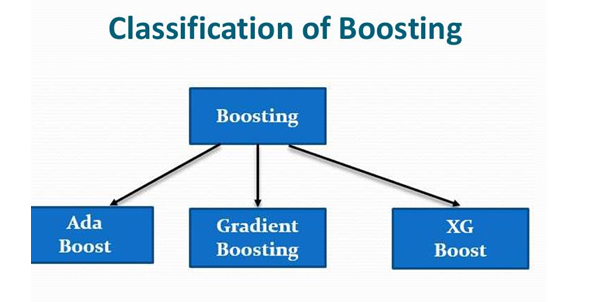

### AdaBoost (Adaptive Boosting)
- AdaBoost (Adaptive Boosting) is a Boosting algorithm that combines multiple weak learners (usually decision stumps or shallow decision trees) to create one strong learner.
- It works by training models sequentially, where each new model focuses more on the samples that were incorrectly classified by the previous model.

- Specially popular in image classification before CNN and Deep Learning, but not first 
choice nowadays in ML.
- Understanding the concept of math behind Ada Boost helps to understand the 
advance concept of Gradient Boosting and XG Boost.
- AdaBoost assigns weights to each training instance and adjusts the weights at each 
iteration.
- It increases the weights of misclassified instances while decreases the weights of correctly classified instances.
- In AdaBoost, the weak learner is usually a Decision Stump (A Decision Tree with only one split (depth = 1).).

#### Additive Modelling Idea 
- It is a kind of additive modeling. Where the boosting builds the model in a stage
wise manner by adding one weak learner at a time.

    F(x) = f1(x) + f2(x)+…………….. + fn(x)

#### Things to keep in mind
- Weak learner( accuracy just >=50%)
- Decision Stump: It is a tree with one node and two leaves.(shallow tree i.e. max 
depth = 1) or only one decision in a model. 
- They are not good at making accurate classifications. They are technically "weak 
learners". 
- +1 and -1( positive and negative)

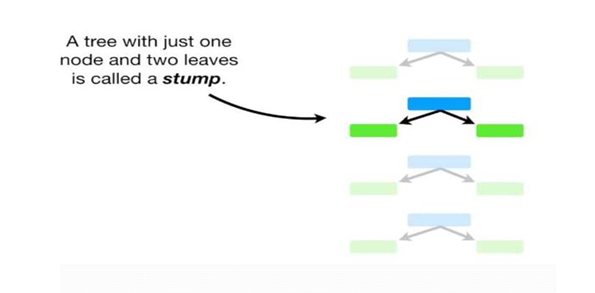

#### Algorithm Steps:
1. Initialize instance weights uniformly.
2. Train a weak learner on the weighted dataset.
3. Calculate the error of the weak learner.
4. Adjust instance weights based on the error.
5. Increase the weights of misclassified instances and decrease the weight of correctly 
classified.
6. Repeat until a predefined number of weak learners is reached.

Start

↓

Assign equal weights to all samples

↓

Train Decision Stump

↓

Find wrongly classified samples

↓

Increase their weights

↓

Train next stump

↓

Repeat

↓

Combine all stumps using weighted voting

↓

Final Prediction

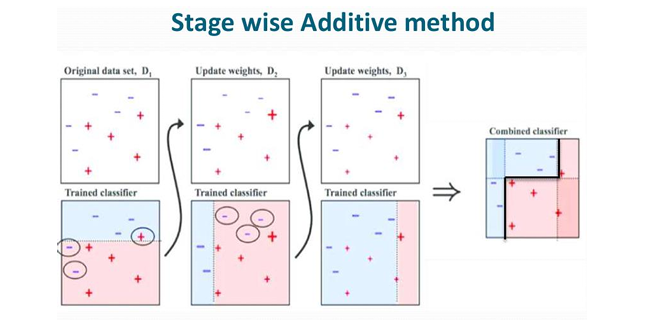

#### Important Hyperparameters
1. n_estimator : no. of week learners.
2. learning_rate : controls how much each stump contributes.
3. estimator : specifies which weak learner to use.

#### Advantages:
- Simple and easy to implement.
- Reduces bias.
- Works well on structured/tabular datasets.
- Focuses on difficult samples.
- Often performs much better than a single decision tree.

#### Limitations:
- Sensitive to noisy data.
- Sensitive to outliers.
- Sequential training makes it slower than Bagging.
- Performance may decrease if many labels are incorrect.

#### ADA boost with numerical example
- Suppose you have a simple dataset with n observation and for model making took n1 samples.
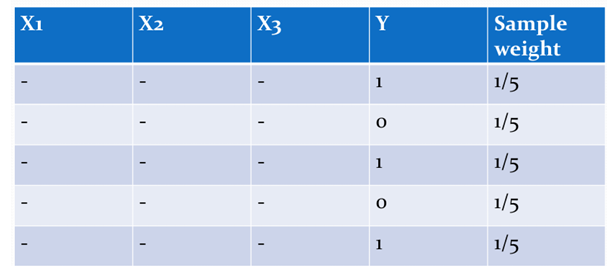

##### Step 1:
- Initialization:
- Weights are initialized uniformly: 1 / no of rows
- 𝑤1=𝑤2=𝑤3=𝑤4=𝑤5 = 1/5

##### Step 2:
- Calculate total error: sum of sample weight for wrong prediction. Here it is : (1/5)+(1/5) = 2/5 
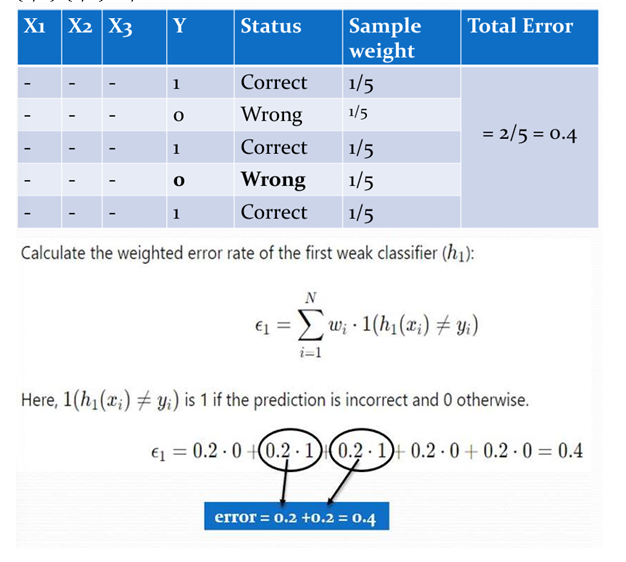

##### Step 3:
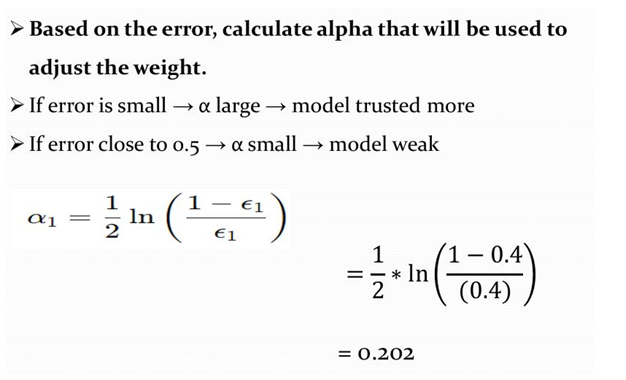

##### Step 4:
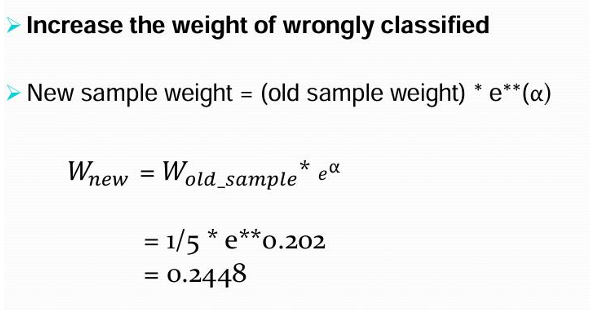

##### Step 5:
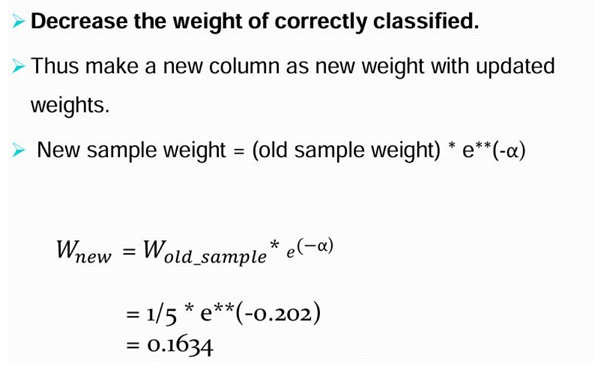

##### Step 6: Update the weight
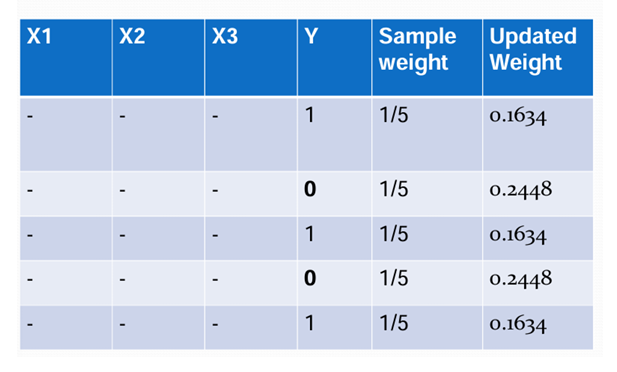

##### Step 7: Normalize the weight
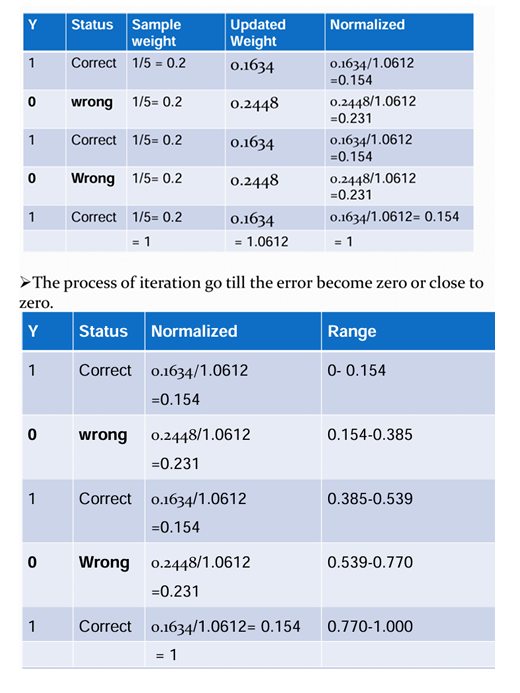

#### Range
- The "Range" is a visual representation that shows how the model will give more 
importance to previously misclassified samples in the next iteration.
- The cumulative addition of normalized weights shows the probability intervals. The 
larger ranges (e.g., 0.166 - 0.416) indicate that misclassified samples have a higher 
chance of being selected in the next iteration.

    ##### Steps 6:
  - Continue the process till the results get optimized in terms of time, memory and 
overfitting with correct classification

#### Final Model
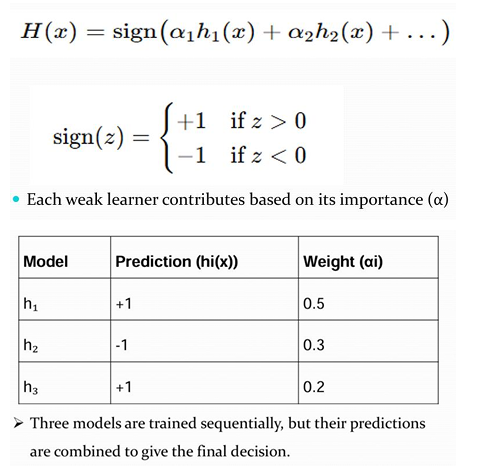

#### Why Boosting reduces Bias?
Ans.Boosting reduces bias because each new weak learner is trained to correct the mistakes of the previous learners. As these corrections accumulate, the combined model captures the underlying pattern more accurately, reducing underfitting (high bias).

### Gradient Descent
- Gradient Descent is an optimization algorithm used to minimize the error (loss function) by updating the model's parameters step by step.
- It is used to train machine learning models such as Linear Regression, Logistic Regression, and Neural Networks.
- It keeps updating the model until the error becomes as small as possible.

#### Formula
New Parameter = Old Parameter − Learning Rate × Gradient

where:
- Learning Rate (α): Controls the step size.
- Gradient: Shows the direction of maximum increase in loss.
- We move in the opposite direction to reduce the loss

#### Advantages
- Simple and efficient.
- Works well with large datasets.
- Used in most modern ML and Deep Learning algorithms.

#### Limitations
- Choosing the wrong learning rate can make training very slow or unstable.
- May get stuck in local minima (depending on the problem).


### Gradient Boosting
- Gradient Boosting is a Boosting ensemble algorithm that builds multiple decision trees sequentially.
- Instead of increasing the weights of misclassified samples (like AdaBoost), each new tree is trained to predict the errors (residuals) made by the previous trees.
- Why is it called Gradient Boosting?
    - The algorithm minimizes a loss function by using the gradient (direction of steepest decrease) of that loss.
    - Instead of directly updating model parameters (like Gradient Descent), it adds a new tree that points in the direction that most reduces the loss.

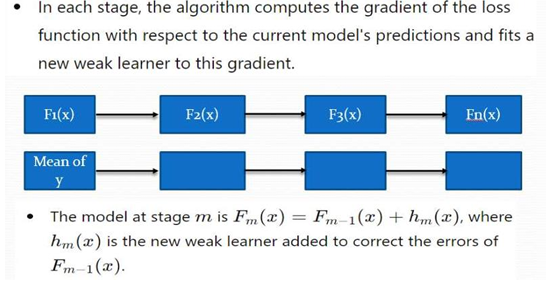

#### Advantages
- Very high prediction accuracy.
- Works well for both classification and regression.
- Handles complex, non-linear relationships.
- Foundation of popular algorithms like XGBoost, LightGBM, and CatBoost

#### Limitations
- Slower because trees are built one after another.
- Can overfit if too many trees are added.
- Requires careful hyperparameter tuning.

#### Interpretation of F1(x)
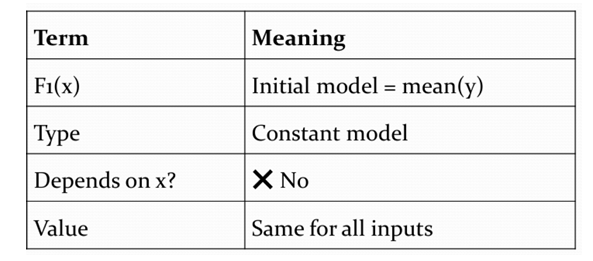

- Each weak learner focuses on improving the overall model by addressing the errors 
(residuals) of the previous ensemble.

#### Loss Function
- A Loss Function is a mathematical function that measures how wrong a model's predictions are compared to the actual values.
- In simple words;
    - Loss Function = Prediction Error
 
- Why do we need a Loss Function?
    -  Without a loss function, the model has no way of knowing whether its predictions are good or bad.
 
- Relation with Gradient Descent:
    -  Gradient Descent asks one question repeatedly:
        - "How can I reduce the loss?"
    - Its goal is to find the model parameters that make the loss as small as possible.

So, 
- Loss Function tells us how wrong the prediction is.
- Gradient Descent tells us how to reduce that wrongness.

- Relation with Gradient Boosting:
    -  Gradient Boosting also wants to reduce the loss.
    - Instead of changing model parameters, it adds a new decision tree that learns from the remaining errors.
    - So Gradient Boosting keeps adding trees until the loss becomes very small.
      
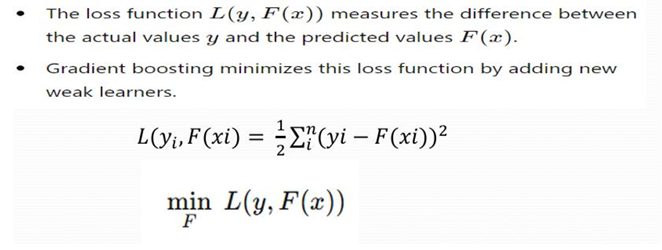

### Algorithm behind Gradient Boosting
- Inputs for start: training set{(xi,yi)}for n values, 
- Differentiable loss function 
- Number of iterations M
  
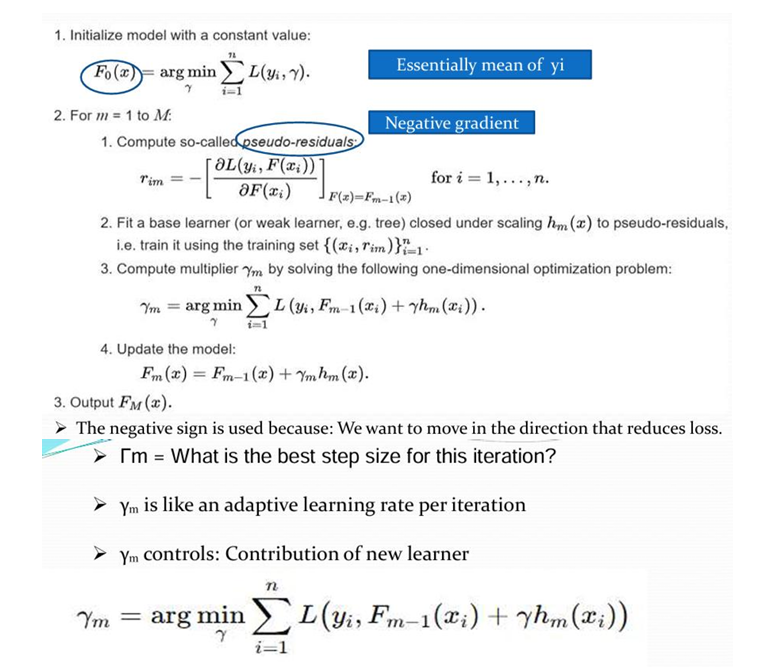
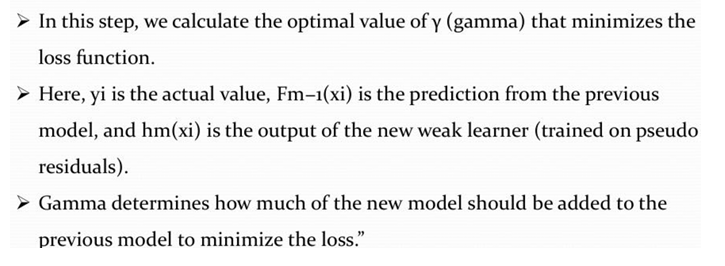
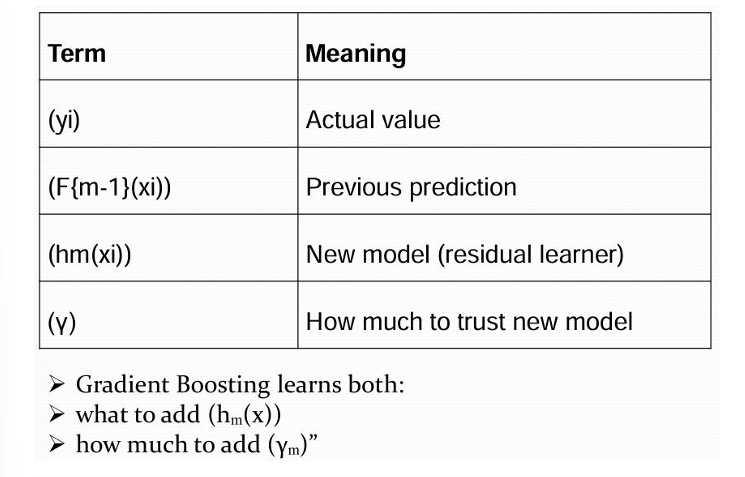
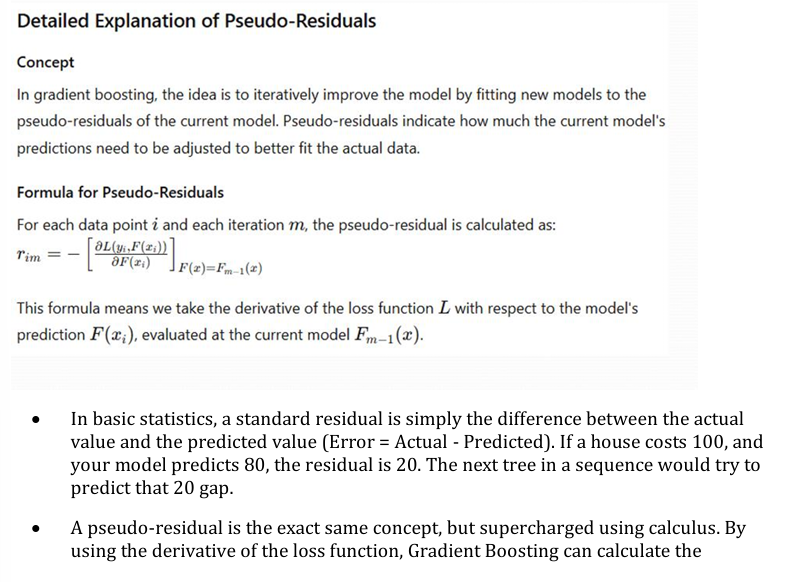
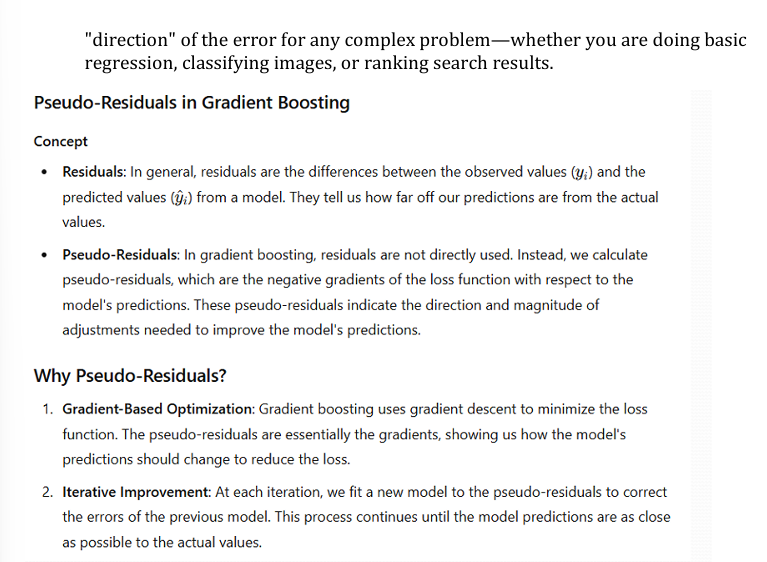

### How GB differs from AdaBoost
#### Gradient Boosting:
- Boosting Method: Gradient Boosting builds models sequentially, where each new 
model tries to correct the errors of the previous models. It does this by fitting the 
new model to the residual errors (the difference between the actual and 
predicted values) of the previous model. 
- Loss Function: It explicitly minimizes a specified loss function (e.g., mean squared 
error for regression, log-loss for classification) using gradient descent. Each new 
model is added to reduce this loss. 
- Model Updates: The model at each stage i supdated by adding thenew model that 
predicts the residuals. Formally, the model 𝐹𝑚(𝑥) at stage 𝑚 isgiven by: where 𝜈 is 
the learning rate and ℎ𝑚(𝑥) is the new weak learner.
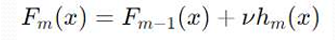
- Flexibility: Gradient Boosting is more flexible as it can optimize any differentiable 
loss function. 

#### Adaptive Boosting (AdaBoost):
- Boosting Method: AdaBoost also builds models sequentially, but it adjusts the 
weights of the training instances based on the errors of the previous models. 
Instances that are misclassified by previous models get higher weights so that 
subsequent models focus more on them. 
- Error Focus: AdaBoost directly uses the classification error to update the weights of 
the training instances. Each weak learner is trained on the weighted dataset. 
- Model Weighting: The final model is a weighted sum of the weak learners, where 
each weak learner is weighted based on its accuracy. Formally, the final model 𝐻(𝑥)) 
is given by:
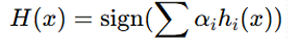

### Gradient Boosting with Different Loss Functions 
- In gradient boosting, you can choose from a variety of loss functions depending on 
the specific problem and the nature of tha data. Common loss functions used in gradient boosting include:
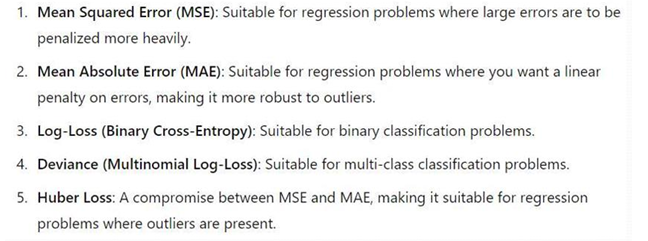

### Hyper parameters in gradient boosting

#### Number of Estimators (n_estimators) 
- Description: The number of boosting stages (trees) to be built. 
- Effect: Increasing the number of estimators generally improves the model's 
performance up to a certain point, after which it can lead to overfitting. 
- Typical Values: 100 to 1000, but it depends on the complexity of the dataset.

#### Learning Rate (learning_rate) 
- Description: Also known as the shrinkage rate, it controls the contribution of each 
weak learner. 
- Effect: A lower learning rate requires a larger number of estimators for the model to 
perform well. It helps in preventing overfitting. 
- Typical Values: 0.01 to 0.1

#### Maximum Depth (max_depth) 
- Description: The maximum depth of the individual trees. 
- Effect: Controls the complexity of the trees. Deeper trees can capture more complex 
patterns but are more prone to overfitting. 
- Typical Values: 3 to 10.

#### Max Features (max_features) 
- Description: The number of features to consider when looking for the best split. 
- Effect: Reduces overfitting by limiting the number of features each tree can use. 
- Typical Values: 'auto' (all features), 'sqrt' (square root of the number of features), 
'log2' (logarithm base 2 of the number of features).

#### Loss Function (loss) 
- Description: The loss function to be minimized. 
- Effect: Different loss functions are used for regression and classification tasks. 
- Typical Values: 'deviance' (log-loss for classification), 'exponential' (AdaBoost-like 
for classification), 'ls' (least squares regression), 'lad' (least absolute deviation for regression), 'huber' (combination of least squares and least absolute deviation).

#### Alpha 
- Description: The quantile for Huber loss and quantile loss. 
- Effect: Controls the robustness of the loss function to outliers. 
- Typical Values: 0.9 for Huber loss. 

### Extreme Gradient Boosting (XGBoost) 
- XGBoost (Extreme Gradient Boosting) is an advanced and optimized implementation of Gradient Boosting. It builds multiple decision trees sequentially, where each new tree learns from the errors (residuals) of the previous trees.
- It is designed to be faster, more accurate, and less prone to overfitting than traditional Gradient Boosting.

#### Why is it called "Extreme" Gradient Boosting?
Because it improves Gradient Boosting by adding:

⚡ Faster training

🧠 Better accuracy

🛡️ Regularization to reduce overfitting

💻 Parallel processing

🚀 Efficient memory usage

### XGBoost vs Standard Gradient Boosting
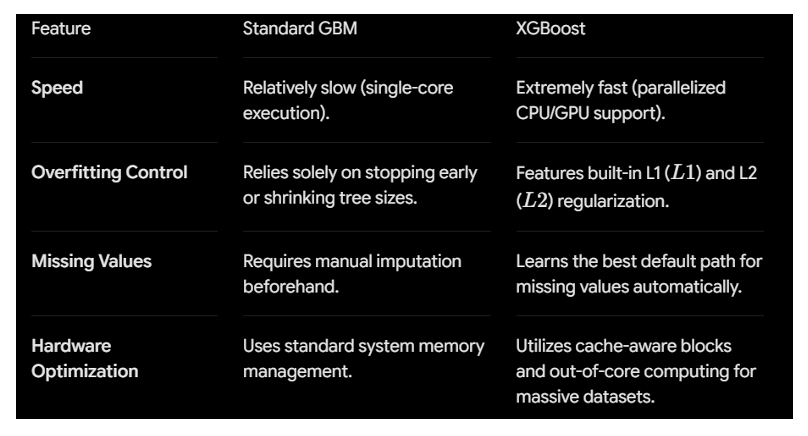

### Key Features of XGBoost 
#### Regularization:
- XGBoost includes L1 (Lasso) and L2 (Ridge) regularization to prevent overfitting 
and improve the generalization of the model. 
- Regularization parameters include alpha (L1 regularization) and lambda (L2 
regularization).

#### Handling Missing Values: 
- XGBoost has built-in support for handling missing values, automatically learning the 
best imputation strategy from the data.

#### Parallel Processing: 
- XGBoost can leverage multiple CPU cores for parallel processing, making it much 
faster than traditional gradient boosting implementations.

#### Tree Pruning: 
- Instead of growing trees to a fixed depth, XGBoost uses a max-depth parameter 
along with a minimum loss reduction required to make a further partition, 
effectively pruning trees during training.

#### Tree Pruning: 
- Instead of growing trees to a fixed depth, XGBoost uses a max-depth parameter 
along with a minimum loss reduction required to make a further partition, 
effectively pruning trees during training.

### HyperParameters in XGBoost 
- Here are some of the critical hyperparameters in XGBoost and their typical values: 
- n_estimator: No of decision tree 
- eta (learning rate): [0.01, 0.1] 
- max_depth: Maximum depth of the tree. Typical values range from 3 to 10.

#### From Industry point of view three models are sufficient: 
- Random Forest( high variance) 
- Gradient Boosting(high bias) 
- XG Boosting(high bias)

### AdaBoost vs Gradient Boosting vs XGBoost
| AdaBoost                         | Gradient Boosting                   | XGBoost                                  |
| -------------------------------- | ----------------------------------- | ---------------------------------------- |
| Focuses on misclassified samples | Learns residual errors              | Learns residual errors with optimization |
| Uses sample weights              | Uses gradients of the loss function | Uses gradients + regularization          |
| Simpler                          | More accurate                       | Fastest and often most accurate          |
| Usually decision stumps          | Decision trees                      | Optimized decision trees                 |


### Practice

In [1]:
import numpy as np
import pandas as pd

df = pd.DataFrame([[165,137,472,192],[101,92,250,144],[29,127,201,91]],columns=['R&D','Ops','Marketing','Profit'])

In [2]:
df

,R&D,Ops,Marketing,Profit
0,165,137,472,192
1,101,92,250,144
2,29,127,201,91


In [3]:
df['f0(x)'] = df['Profit'].mean()
# put mean of profit in f0(x)

In [4]:
df

,R&D,Ops,Marketing,Profit,f0(x)
0,165,137,472,192,142.333333
1,101,92,250,144,142.333333
2,29,127,201,91,142.333333


In [5]:
df['r1'] = df['Profit'] - df['f0(x)']

In [6]:
df

,R&D,Ops,Marketing,Profit,f0(x),r1
0,165,137,472,192,142.333333,49.666667
1,101,92,250,144,142.333333,1.666667
2,29,127,201,91,142.333333,-51.333333


In [7]:
from sklearn.tree import DecisionTreeRegressor as dtr
reg = dtr(max_depth=3)
reg.fit(df.iloc[:,0:3].values, df.iloc[:,-1])
# spliting into dep and indep variable
# R&D to Marketing --> indep
# r1 --> dep

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes m

[Text(0.4, 0.8333333333333334, 'x[2] <= 225.5\nsquared_error = 1701.556\nsamples = 3\nvalue = -0.0'),
 Text(0.2, 0.5, 'squared_error = 0.0\nsamples = 1\nvalue = -51.333'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 361.0\nsquared_error = 576.0\nsamples = 2\nvalue = 25.667'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = 1.667'),
 Text(0.8, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = 49.667')]

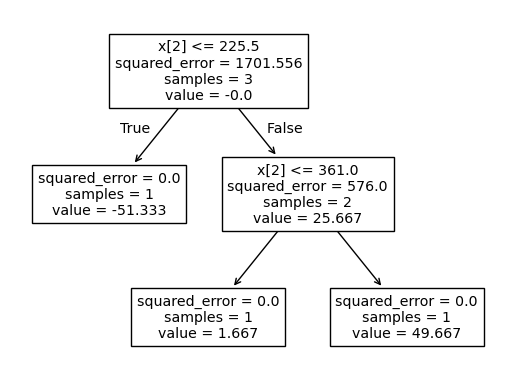

In [8]:
from sklearn.tree import plot_tree
plot_tree(reg)

### Gradient Boosting step-by-step

In [9]:
import numpy as np
import pandas as pd

In [10]:
np.random.seed(42)  #random_state=42
# This means that every time you run the code, you get the same random numbers.
x = np.random.rand(100,1) - 0.5
# Generates 100 random numbers between 0 and 1.
# Subtracts 0.5 from every value.
# So x contains 100 random input values centered around zero.
y = 3*x[:,0]**2 + 0.05 * np.random.randn(100)
# This line creates the target variable (y).
# takes all rows and first column from x (converts (100,1) to (100,))
# then squares every value and then multiply with 3.
# 3*x[:,0]**2 --> This creates a parabolic (quadratic) relationship.
# This generates 100 random numbers from a normal (Gaussian) distribution.
# Unlike rand(), these numbers are not limited to 0 and 1
# Multiplies the random noise by 0.5. This reduces the amount of noise.

In [11]:
y

array([ 5.15728987e-02,  5.94479790e-01,  1.66051606e-01, -7.01779562e-02,
        3.43985933e-01,  3.72874939e-01,  6.59764984e-01,  3.76341398e-01,
       -9.75194335e-03,  1.04794741e-01,  7.35287787e-01,  6.78883363e-01,
        3.05066318e-01,  2.73909733e-01,  3.08559932e-01,  3.49130363e-01,
        7.98606436e-02, -1.45444646e-02, -5.71096619e-03,  5.75800683e-02,
        5.23392240e-02,  4.02946793e-01,  1.29867214e-01,  4.18481141e-02,
       -6.49789982e-02,  2.22943721e-01,  2.53451786e-01, -3.95060058e-02,
        1.75570720e-02,  6.37324227e-01,  1.29006981e-01,  3.34391950e-01,
        5.80417870e-01,  6.00772381e-01,  5.54501010e-01,  2.84001079e-01,
        1.17538848e-01,  6.08765289e-01,  9.22073759e-02,  2.58225391e-02,
        4.26829699e-01, -5.83641153e-02,  7.07523289e-01,  5.40226226e-01,
        2.14112889e-01,  3.37711060e-02,  1.76497872e-01, -6.88843767e-02,
        3.58884053e-02,  4.07472924e-01,  6.12002352e-01,  1.98779325e-01,
        5.84460527e-01,  

In [12]:
x

array([[-0.12545988],
       [ 0.45071431],
       [ 0.23199394],
       [ 0.09865848],
       [-0.34398136],
       [-0.34400548],
       [-0.44191639],
       [ 0.36617615],
       [ 0.10111501],
       [ 0.20807258],
       [-0.47941551],
       [ 0.46990985],
       [ 0.33244264],
       [-0.28766089],
       [-0.31817503],
       [-0.31659549],
       [-0.19575776],
       [ 0.02475643],
       [-0.06805498],
       [-0.20877086],
       [ 0.11185289],
       [-0.36050614],
       [-0.20785535],
       [-0.13363816],
       [-0.04393002],
       [ 0.28517596],
       [-0.30032622],
       [ 0.01423444],
       [ 0.09241457],
       [-0.45354959],
       [ 0.10754485],
       [-0.32947588],
       [-0.43494841],
       [ 0.44888554],
       [ 0.46563203],
       [ 0.30839735],
       [-0.19538623],
       [-0.40232789],
       [ 0.18423303],
       [-0.05984751],
       [-0.37796177],
       [-0.00482309],
       [-0.46561148],
       [ 0.4093204 ],
       [-0.24122002],
       [ 0

In [13]:
df = pd.DataFrame()
df['x'] = x.reshape(100)
# reshape() changes the shape (dimensions) of an array without changing its data. 
# It converts the 2D array into a 1D array.
df['y'] = y

In [14]:
df

,x,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


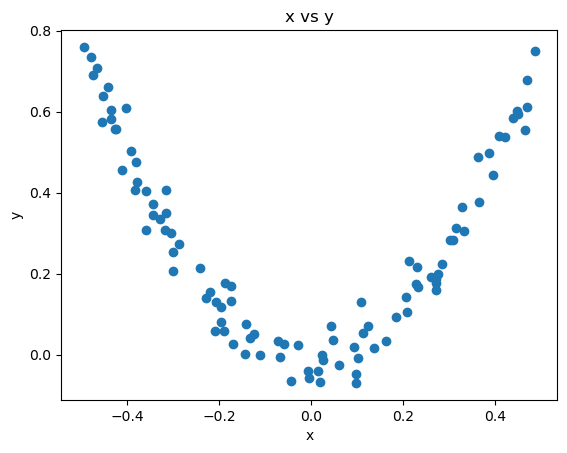

In [15]:
import matplotlib.pyplot as plt
plt.scatter(df['x'], df['y'])
plt.title('x vs y')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

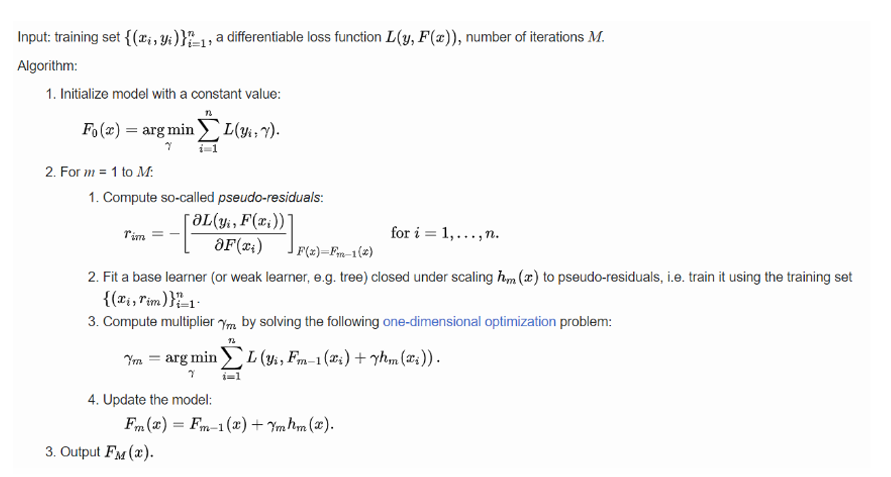

In [16]:
df['pred1'] = df['y'].mean()

In [17]:
df.head()

,x,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


In [18]:
df['res1'] = df['y'] - df['pred1']
# This calculates the residuals (errors).

In [19]:
df.head()

,x,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


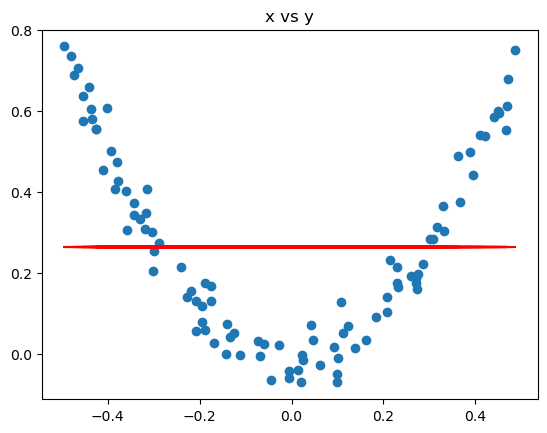

In [20]:
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], df['pred1'], color = 'red')
plt.title('x vs y')
plt.show()

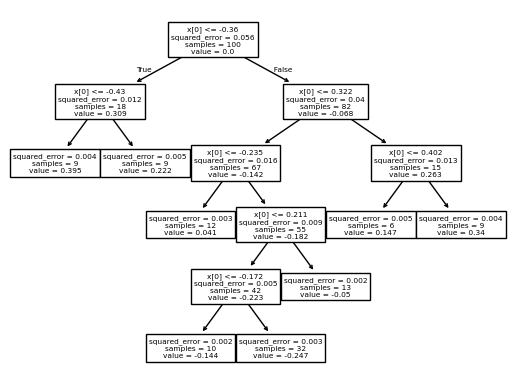

In [21]:
from sklearn.tree import DecisionTreeRegressor 

tree1 = DecisionTreeRegressor(max_leaf_nodes=8) 

tree1.fit(df['x'].values.reshape(100,1), df['res1'].values) 

from sklearn.tree import plot_tree 
plot_tree(tree1) 
plt.show()

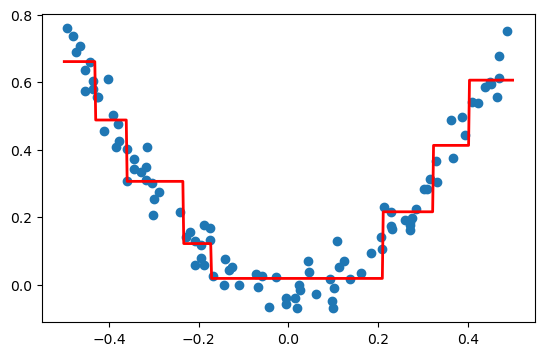

In [22]:
x_test = np.linspace(-0.5, 0.5, 500)
# np.linspace(start, end, number_of_points)
# It creates equally spaced numbers.

y_pred =  0.265458 + tree1.predict(x_test.reshape(500,1))
# tree1 was trained on the residuals, not on the original y.
# So its predictions are corrections, not final outputs.
# 0.265458 is the mean of y. This was the model's first prediction.
# New Prediction = Old Prediction + Correction

plt.figure(figsize=(14,4)) 
plt.subplot(121) 
# 121 means 1 row, 2 columns, and current graph = 1st pos
plt.plot(x_test, y_pred, linewidth=2, color='red') 
plt.scatter(df['x'], df['y']) 
plt.show() 


In [23]:
df['pred2'] = 0.265458 + tree1.predict(df['x'].values.reshape(100,1)) 
df

,x,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018319
4,-0.343981,0.343986,0.265458,0.078528,0.305964
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319
96,0.022733,-0.002305,0.265458,-0.267763,0.018319
97,-0.072459,0.032809,0.265458,-0.232650,0.018319
98,-0.474581,0.689516,0.265458,0.424057,0.660912


In [24]:
df['res2'] = df['y'] - df['pred2']
df

,x,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


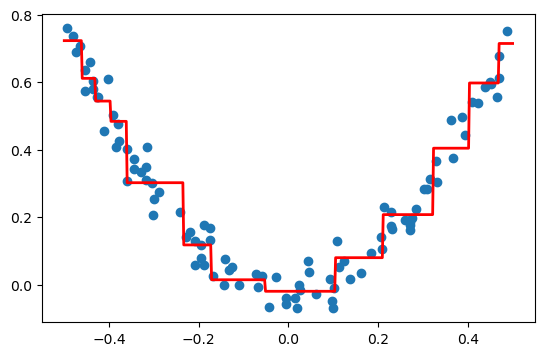

In [25]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8) 
tree2.fit(df['x'].values.reshape(100,1), df['res2'])

y_pred = 0.265458 + sum(regressor.predict(x_test.reshape(-1,1)) for regressor 
in [tree1, tree2]) 

plt.figure(figsize=(14,4)) 
plt.subplot(121) 
plt.plot(x_test, y_pred, linewidth=2, color='red') 
plt.scatter(df['x'], df['y']) 
plt.show()

5


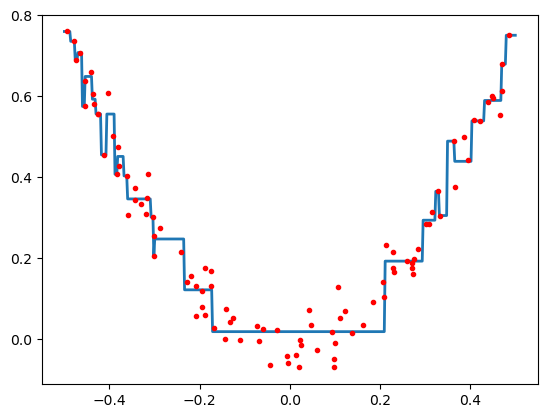

4


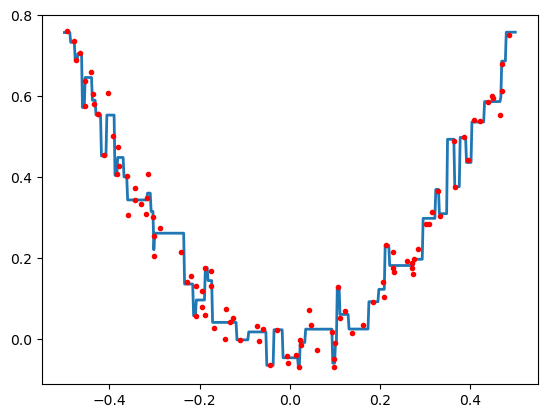

3


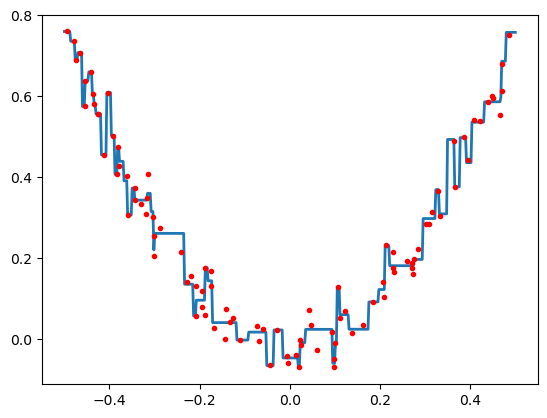

2


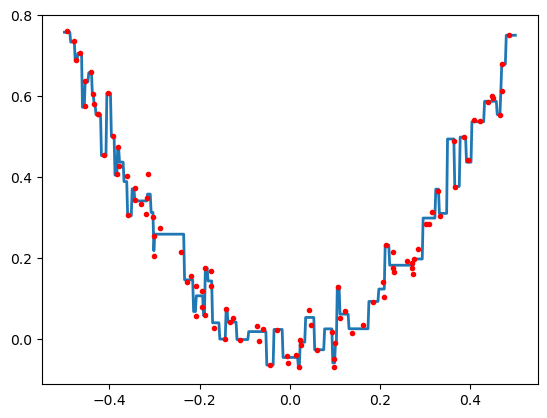

1


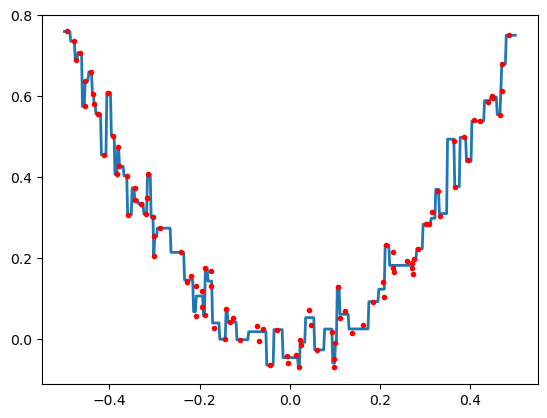

In [32]:
def gradient_boost(x, y, number, lr, count=1, regs=[], foo=None): 
# x - input features
# y - target values
#  number - no. of trees left to train
# lr - learning rate.
# Instead of taking the full correction, each tree only nudges the prediction a little. This makes the model learn more gradually and usually improves generalization.
# count - keeps track of which tree we're training
# regs - stores all the trained decision tree
# foo - stores the original target values
    if number==0: 
        return 
    else: 
        # do gradient boosting 
        if count > 1 :   
            y = y - regs[-1].predict(x)  #regs[-1].predict(x) means predictions of the most recently trained tree
        else: 
            foo = y   #cuz for the first tree there are no residuals yet, so foo=y
             
        tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42) 
        tree_reg.fit(x, y) 
        regs.append(tree_reg) 
         
        x1 = np.linspace(-0.5, 0.5, 500)    #Creates 500 equally spaced values for a smooth graph.
        y_pred = sum(lr * regressor.predict(x1.reshape(-1,1)) for regressor 
in regs) 
         
        print(number)
        
        plt.figure() 
        plt.plot(x1, y_pred, linewidth=2) 
        plt.plot(x[:,0], foo, 'r.') 
        # red - actual data
        # clue - current prediction
        plt.show() 
         
        gradient_boost(x, y, number-1, lr, count+1, regs, foo=foo)

np.random.seed(42) # random_state=42
x = np.random.rand(100,1) - 0.5 
y = 3*x[:, 0]**2 + 0.05 * np.random.randn(100) 
gradient_boost(x, y, 5, lr=1)

ROC (Receiver Operating Characteristic) Curve is a graphical tool used to evaluate the performance of a binary classification model by plotting the True Positive Rate (Recall) against the False Positive Rate for different classification thresholds.

AUC stands for Area Under the ROC Curve

It measures how good your classifier is at separating the two classes.

What does AUC tell us?

It answers one simple question:

    "How well can the model distinguish Positive samples from Negative samples?"

A larger AUC means the model is better at ranking positive samples above negative ones

In [33]:
from sklearn.linear_model import LogisticRegression 

import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.datasets import make_classification 

In [36]:
# Generate a synthetic dataset 
x, y = make_classification(n_samples=1000, n_features=20, n_classes=2, 
random_state=42)
# make_classification: Instead of collecting data from hospitals, banks, or companies, it creates a realistic-looking dataset for us.

In [37]:
# Split the dataset into training and testing sets 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, 
random_state=42)

In [38]:
# Train a logistic regression model 
model = LogisticRegression() 
model.fit(x_train, y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [39]:
# Predict probabilities for the test set 
y_prob = model.predict_proba(x_test)[:, 1]
# .predict_proba gives the percentage of how confident the model is(gives precentage of 0 and 1)
# y_prob contains only the probability of the positive class.

In [42]:
# Compute ROC curve 
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# roc_curve() takes Actual labels(y_test) and Predicted probablities(y_prob) and returns False Positive Rate(FPR), True Positive Rate(TPR), Thresholds

In [43]:
# Compute AUC 
auc = roc_auc_score(y_test, y_prob) 

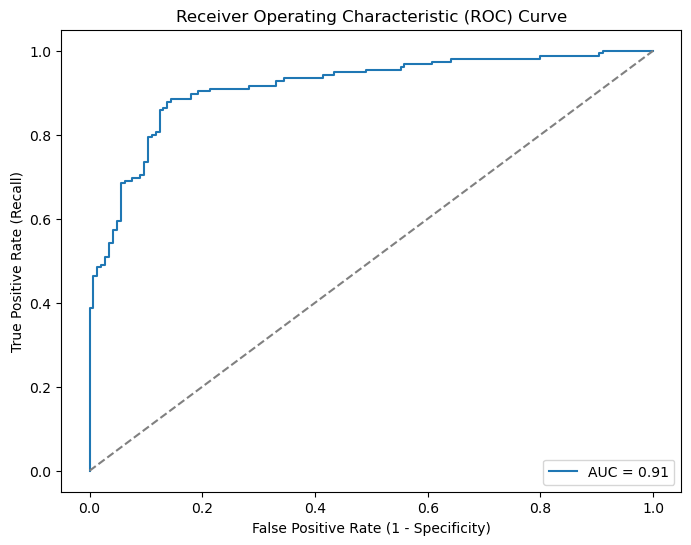

In [44]:
# Plot ROC curve 
plt.figure(figsize=(8, 6)) 
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}') 
plt.plot([0, 1], [0, 1], linestyle='--', color='gray') 
plt.xlabel('False Positive Rate (1 - Specificity)') 
plt.ylabel('True Positive Rate (Recall)') 
plt.title('Receiver Operating Characteristic (ROC) Curve') 
plt.legend(loc='lower right') 
plt.show()